**IIC3912 - Tópicos Avanzados de Gráfica Computacional**\
Francisca T. Gil-Ureta ⋅ 2026

# **Clase 8 | Reconstrucción 3D clasica**
## Keypoints y correspondencias

**Fecha:** 8 de abril de 2026  
**Tiempo estimado:** 30 minutos

En esta práctica vas a detectar puntos de interés en pares de imágenes, calcular correspondencias entre ellos, y explorar cuándo y por qué el matching falla — el primer eslabón del pipeline de reconstrucción 3D.

In [ ]:
import os, urllib.request

from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100

# ── Descarga imágenes ──────────────────────────────────────────────────────────
output_folder = Path("output")
output_folder.mkdir(exist_ok=True, parents=True)

def _download(url, path):
    if not Path(path).exists():
        urllib.request.urlretrieve(url, output_folder / path)

# Par 1: caja de cereal — dos vistas con textura rica (imágenes de muestra de OpenCV)
_download(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png",
    "textured_1.png"
)
_download(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png",
    "textured_2.png"
)

# ── Genera imágenes sintéticas ─────────────────────────────────────────────────

def _make_low_texture():
    """Superficie lisa: gradiente suave con ruido mínimo."""
    rng = np.random.default_rng(42)
    h, w = 480, 640
    xx, yy = np.meshgrid(np.linspace(30, 220, w), np.linspace(60, 180, h))
    img = np.clip(xx * 0.4 + yy * 0.6 + rng.normal(0, 2, (h, w)), 0, 255).astype(np.uint8)
    return img

def _make_grid():
    """Patrón repetitivo: grilla regular con ruido mínimo."""
    rng = np.random.default_rng(42)
    h, w = 480, 640
    img = np.full((h, w), 200, dtype=np.uint8)
    for i in range(0, h, 40):
        img[i:i+3, :] = 40
    for j in range(0, w, 40):
        img[:, j:j+3] = 40
    img = np.clip(img.astype(float) + rng.normal(0, 2, (h, w)), 0, 255).astype(np.uint8)
    return img

def _rotate(img, angle_deg):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(img, M, (w, h))

# Par 2: superficie lisa — original + rotada 15°
lt = _make_low_texture()
cv2.imwrite(output_folder / "low_texture_1.png", lt)
cv2.imwrite(output_folder / "low_texture_2.png", _rotate(lt, 15))

# Par 3: patrón repetitivo — original + rotada 8°
gr = _make_grid()
cv2.imwrite(output_folder / "grid_1.png", gr)
cv2.imwrite(output_folder / "grid_2.png", _rotate(gr, 8))

print("Setup complete.")

Setup complete.


## Contexto

En la clase de hoy formalizamos la reconstrucción 3D como un problema inverso: dadas varias imágenes, queremos recuperar la geometría de la escena. El primer paso del pipeline — Structure from Motion — depende de encontrar puntos correspondientes entre fotos del mismo objeto tomadas desde ángulos distintos. Sin esas correspondencias, no hay forma de estimar las poses de la cámara ni reconstruir ningún punto 3D.

El pipeline no puede saber qué pixel en una imagen corresponde a qué pixel en otra. Necesita **detectores** que encuentren ubicaciones repetibles y **descriptores** que distingan esas ubicaciones aunque la cámara se haya movido. Lo que detectemos acá es, literalmente, la entrada de SfM.

---

> ### Pregunta central
> **¿Cuándo y por qué falla el matching de keypoints — y qué nos dice eso sobre el pipeline que viene después?**

In [ ]:
# ── Funciones del pipeline de keypoints ───────────────────────────────────────

def load_gray(path):
    bgr = cv2.imread(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), bgr

def match_sift(img1_gray, img2_gray, n_features=500):
    sift = cv2.SIFT_create(nfeatures=n_features)
    kp1, des1 = sift.detectAndCompute(img1_gray, None)
    kp2, des2 = sift.detectAndCompute(img2_gray, None)
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return kp1 or [], kp2 or [], []
    bf = cv2.BFMatcher(cv2.NORM_L2)
    raw = bf.knnMatch(des1, des2, k=2)
    # ratio test de Lowe: descarta matches ambiguos
    good = [m for m, n in raw if m.distance < 0.75 * n.distance]
    return kp1, kp2, good

def match_orb(img1_gray, img2_gray, n_features=500):
    orb = cv2.ORB_create(nfeatures=n_features)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)
    if des1 is None or des2 is None:
        return kp1 or [], kp2 or [], []
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)
    return kp1, kp2, matches

def show_matches(img1_bgr, kp1, img2_bgr, kp2, matches, title, max_matches=60):
    vis = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2,
        matches[:max_matches], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(14, 5))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    n = len(matches)
    plt.title(f"{title}  —  {n} matches (mostrando {min(n, max_matches)})", fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


---
### Pregunta 1

Corran el notebook con las imágenes de ejemplo. **¿Cuántos matches aparecen? ¿Se ven razonables, o hay líneas cruzadas que no tienen sentido?**

Fíjense en la distribución espacial de los keypoints: ¿se concentran en alguna zona? ¿Por qué ahí y no en otra?

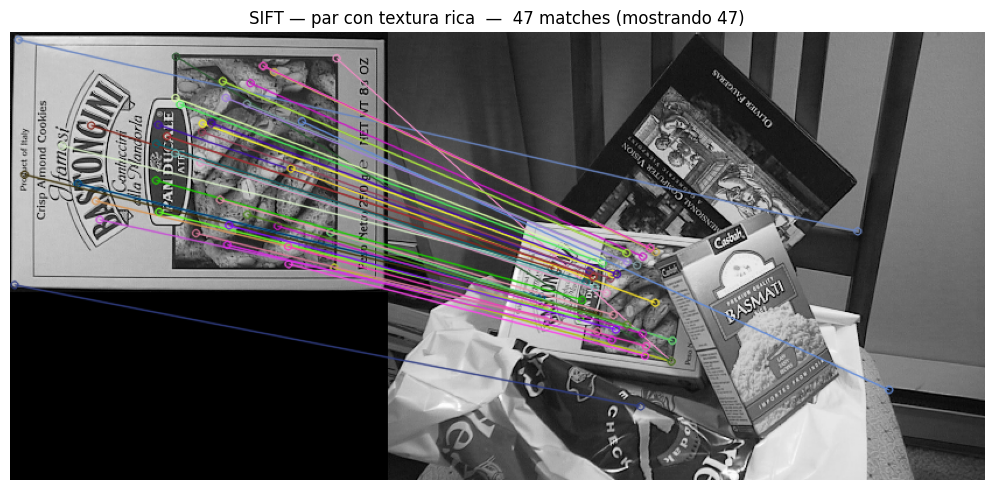

In [ ]:
gray1, bgr1 = load_gray(output_folder / "textured_1.png")
gray2, bgr2 = load_gray(output_folder / "textured_2.png")

kp1_s, kp2_s, m_s = match_sift(gray1, gray2)
show_matches(bgr1, kp1_s, bgr2, kp2_s, m_s, "SIFT — par con textura rica")


---
### Pregunta 2

El notebook usa dos detectores:

- **SIFT** *(Scale-Invariant Feature Transform)*: detecta regiones con gradientes de intensidad bien definidos y las describe con un vector de 128 números flotantes. Robusto a escala y rotación; usa el ratio test de Lowe para filtrar matches ambiguos.
- **ORB** *(Oriented FAST and Rotated BRIEF)*: alternativa rápida y libre de patentes. Describe los keypoints con un vector binario de 256 bits — compara píxeles vecinos en lugar de calcular gradientes. Mucho más rápido, algo menos robusto.

**Antes de cambiar nada:** ¿cuál esperarían que funcione mejor sobre este par de imágenes, y por qué?

Ahora comparen los resultados. **¿Coincide con lo que esperaban?** ¿Qué diferencias observan — en cantidad de matches, en distribución espacial, en calidad visual de las líneas?

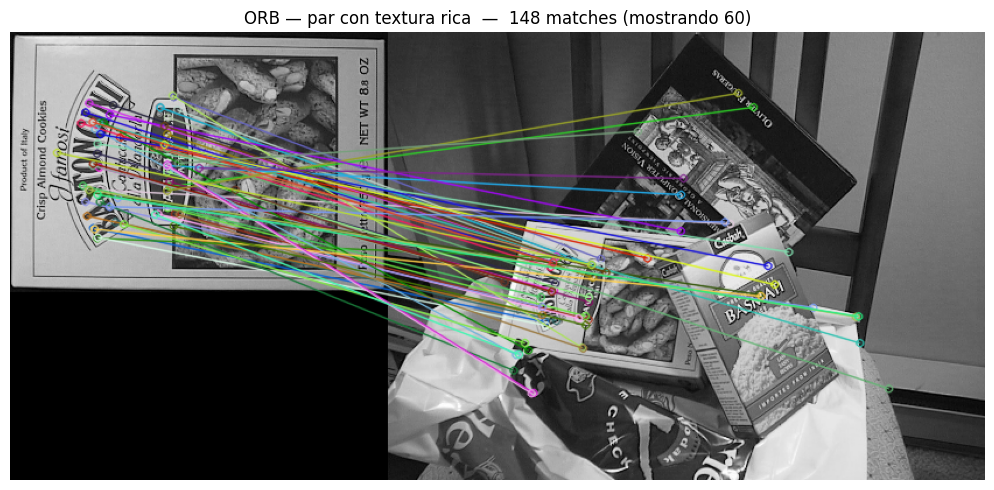

In [ ]:

kp1_o, kp2_o, m_o = match_orb(gray1, gray2)
show_matches(bgr1, kp1_o, bgr2, kp2_o, m_o, "ORB — par con textura rica")

---
### Pregunta 3

El notebook incluye un par de imágenes de **superficie con poca textura** (`low_texture_1.png` / `low_texture_2.png`). Son la misma superficie sintética con una rotación de 15° — en principio, el matching debería funcionar.

Corran SIFT y ORB sobre ese par. **¿Qué pasa con los matches?**

¿Qué implica ese resultado para el pipeline de reconstrucción? Si la entrada de SfM son matches, ¿qué pasa cuando la escena tiene zonas sin textura?

---
### Pregunta 4

Ahora prueben el par con **patrón repetitivo** (`grid_1.png` / `grid_2.png`). Es la misma grilla con una rotación de 8°.

**¿Qué problema nuevo aparece?** ¿Es el mismo problema que con poca textura, o es distinto?

Piensen: si un keypoint en la grilla tiene muchos candidatos similares en la otra imagen, ¿cómo decide el matcher cuál es el correcto? ¿Qué efecto tiene eso sobre la salida?

---
### Pregunta 5

Mirando las visualizaciones: hay matches que claramente son correctos (las líneas conectan puntos del mismo lugar en el objeto) y otros que claramente son erróneos (líneas cruzadas, puntos que no corresponden).

**¿Cómo sabrían si un match es "bueno" — no visualmente, sino con un número?**

¿Qué información necesitarían que el notebook no les está dando todavía? ¿Qué asumiría ese criterio sobre la escena o sobre la cámara?

---
### Si terminás antes

SfM asume escena estática y cámara en movimiento.

**¿Un video es una buena fuente de imágenes para este pipeline?** Si tuvieras un video de 30 fps de un objeto, ¿qué frames elegirías para pasarle al matcher — y cuáles descartarías? ¿Por qué no todos?